# Tapex Quick Analysis (TabMWP)

Analyze Tapex predictions: accuracy buckets (free-text, multi-choice, integer, decimal) and error-type distribution with sample errors.


In [1]:
import os, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# Paths (adjust if needed)
DATA_ROOT = "./data/tabmwp"
TEST_SPLIT = "test"
RESULTS_FILE = "/Users/scarlett/Code/PromptPG-Bryanchlela/PromptPG/results/tapex/exp5-tapex-base-best_model_tapex-base_test.json"



In [2]:
# Load data and results
problems = json.load(open(os.path.join(DATA_ROOT, f"problems_{TEST_SPLIT}.json")))
res = json.load(open(RESULTS_FILE))
results = res["results"]
len(problems), len(results)



(7686, 7686)

In [3]:
def is_correct(pid):
    return results[pid].get("true_false", False)

# Accuracy buckets: free-text vs multi-choice, integer vs decimal
buckets = {
    "free_text": [0,0],
    "multi_choice": [0,0],
    "integer_number": [0,0],
    "decimal_number": [0,0],
}

for pid, prob in problems.items():
    choices = prob.get("choices", []) or []
    at = prob.get("ans_type", "other")
    correct = is_correct(pid)

    if len(choices) > 0:
        b = "multi_choice"
    else:
        b = "free_text"
    buckets[b][1] += 1
    buckets[b][0] += int(correct)

    if at in buckets:
        buckets[at][1] += 1
        buckets[at][0] += int(correct)

print("Requested accuracy buckets:")
for k,v in buckets.items():
    total = v[1]
    acc = v[0]/total*100 if total else 0
    print(f"  {k}: {acc:.2f}% (n={total})")



Requested accuracy buckets:
  free_text: 8.25% (n=5694)
  multi_choice: 44.68% (n=1992)
  integer_number: 9.60% (n=4529)
  decimal_number: 3.00% (n=1165)


TAPEX_Base	7.32, 	39.76, 	8.68,  	2.06

In [4]:
def try_float(x):
    try:
        return float(x)
    except Exception:
        return None

def categorize_error(ans, pred):
    num_a = try_float(ans)
    num_p = try_float(pred)

    if ans.lower() in {"yes","no","true","false"}:
        return "wrong_output_boolean" if ans.lower() != pred.lower() else None

    if num_a is None and num_p is None:
        if ans.lower() != pred.lower():
            return "text_mismatch"
        return None

    if num_a is not None and num_p is None:
        return "non_numeric"

    if num_a is None and num_p is not None:
        return "wrong_output_text"

    if math.isclose(num_a, num_p, rel_tol=0, abs_tol=1e-9):
        return None

    if round(num_a, 2) == round(num_p, 2):
        return "rounding_error"

    if math.isclose(abs(num_p), abs(num_a)*10, rel_tol=0.05) or math.isclose(abs(num_p)*10, abs(num_a), rel_tol=0.05):
        return "off_by_factor_10"

    diff = abs(num_p - num_a)
    if diff >= 10 and diff >= 0.2 * abs(num_a):
        return "large_calculation"
    else:
        return "small_calculation"


def get_error_distribution():
    counter = Counter()
    for pid, prob in problems.items():
        r = results[pid]
        if r.get("true_false", False):
            continue
        ans = str(r.get("answer_norm", r.get("answer", "")))
        pred = str(r.get("prediction_norm", r.get("prediction", "")))
        etype = categorize_error(ans, pred)
        counter[etype or "unknown"] += 1
    return counter



Error counts:
  small_calculation: 2666
  text_mismatch: 866
  large_calculation: 2124
  non_numeric: 90
  off_by_factor_10: 342
  wrong_output_boolean: 236
  wrong_output_text: 2


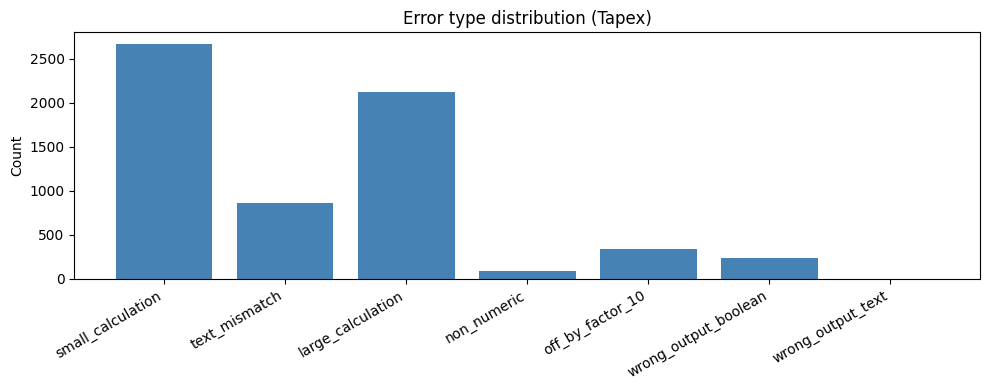

In [5]:
err_counter = get_error_distribution()
print("Error counts:")
for k,v in err_counter.items():
    print(f"  {k}: {v}")

labels = list(err_counter.keys())
values = [err_counter[k] for k in labels]
plt.figure(figsize=(10,4))
plt.bar(labels, values, color="steelblue")
plt.xticks(rotation=30, ha='right')
plt.ylabel("Count")
plt.title("Error type distribution (Tapex)")
plt.tight_layout()
plt.show()



In [6]:
# Compute accuracy via evaluate_acc.py for consistency
import subprocess, shlex

data_file = os.path.join(DATA_ROOT, f"problems_{TEST_SPLIT}.json")
cmd = [
    "python", "evaluate_acc.py",
    "--data_file", data_file,
    "--result_root", os.path.dirname(RESULTS_FILE),
    "--result_files", os.path.basename(RESULTS_FILE),
]
print("Running evaluate_acc:\n", " ".join(shlex.quote(p) for p in cmd))
proc = subprocess.run(cmd, text=True)
print("Return code:", proc.returncode)



Running evaluate_acc:
 python evaluate_acc.py --data_file ./data/tabmwp/problems_test.json --result_root /Users/scarlett/Code/PromptPG-Bryanchlela/PromptPG/results/tapex --result_files exp5-tapex-base-best_model_tapex-base_test.json
Data file:  ./data/tabmwp/problems_test.json
Result file: 
/Users/scarlett/Code/PromptPG-Bryanchlela/PromptPG/results/tapex/exp5-tapex-base-best_model_tapex-base_test.json
number of questions: 7686

acc_free: 	8.25
acc_mc: 	44.68
acc_integer: 	9.60
acc_decimal: 	3.00
acc_extractive: 	41.54
acc_boolean: 	49.22
acc_other: 	35.24
acc_grade_1_6: 	20.74
acc_grade_7_8: 	13.63
acc_average: 	17.70

& 8.25 & 44.68 & 9.60 & 3.00 & 41.54 & 49.22 & 35.24 & 20.74 & 13.63 & 17.70 \\
Return code: 0


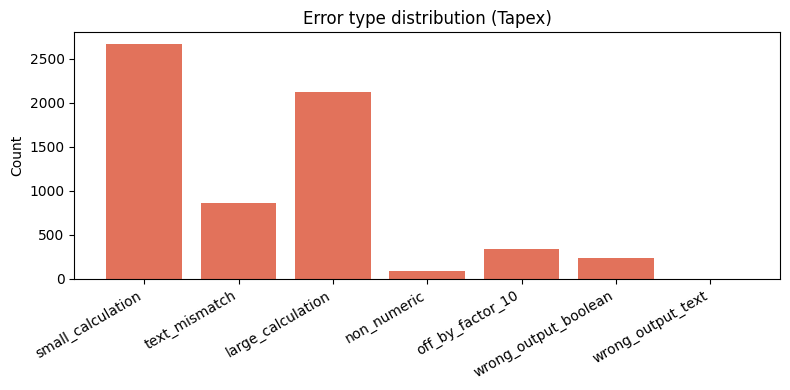

In [13]:
# Bar of error-type distribution
labels = list(err_counter.keys())
values = [err_counter[k] for k in labels]
plt.figure(figsize=(8,4))
plt.bar(labels, values, color="#E2725B")  # terracotta
plt.xticks(rotation=30, ha="right")
plt.ylabel("Count")
plt.title("Error type distribution (Tapex)")
plt.tight_layout()
plt.show()



In [8]:
# Show a few errors by type
sampled = defaultdict(list)
for pid, prob in problems.items():
    r = results[pid]
    if r.get("true_false", False):
        continue
    etype = categorize_error(str(r.get("answer_norm", r.get("answer", ""))), str(r.get("prediction_norm", r.get("prediction", ""))))
    if etype and len(sampled[etype]) < 3:
        sampled[etype].append((pid, prob.get("question", ""), r.get("answer"), r.get("output"), r.get("prediction")))

for etype, rows in sampled.items():
    print(f"\nError type: {etype}")
    for pid, q, ans, out, pred in rows:
        print(f"- pid {pid}\n  Q: {q}\n  answer: {ans}\n  output: {out}\n  prediction: {pred}\n")




Error type: small_calculation
- pid 8
  Q: Hannah baked cookies each day for a bake sale. How many more cookies did Hannah bake on Saturday than on Sunday?
  answer: 18
  output: 16
  prediction: 16

- pid 22
  Q: The employees at Tessa's Construction monitored the number of cracked window panes in each shipment they received. How many shipments had at least 40 cracked window panes but less than 60 cracked window panes?
  answer: 9
  output: 2
  prediction: 2

- pid 31
  Q: How much money does Sidney need to buy a piece of mint chocolate and 7 peanut butter cups?
  answer: 1.47
  output: 7
  prediction: 7


Error type: text_mismatch
- pid 25
  Q: Some friends discussed the sizes of their coin collections. Who has the most coins?
  answer: Hunter
  output: Larry
  prediction: Larry

- pid 85
  Q: Look at the following schedule. Gina just missed the 10.45 A.M. bus at downtown. How long does she have to wait until the next bus?
  answer: 15 minutes
  output: 10:30 A.M.
  prediction: 1 ho

,Metric,Ours,Paper,Diff (Ours-Paper)
0,Avg,17.70,15.73,1.97
1,FREE,8.25,7.32,0.93
2,MC,44.68,39.76,4.92
3,INT,9.60,8.68,0.92
4,DEC,3.00,2.06,0.94
5,EXTR,41.54,35.06,6.48
6,BOOL,49.22,47.11,2.11
7,OTH,35.24,20.95,14.29


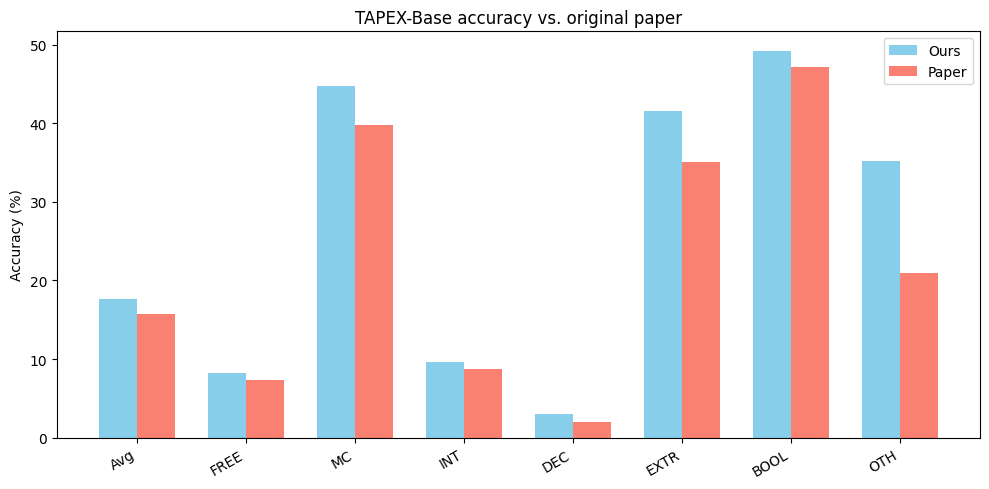

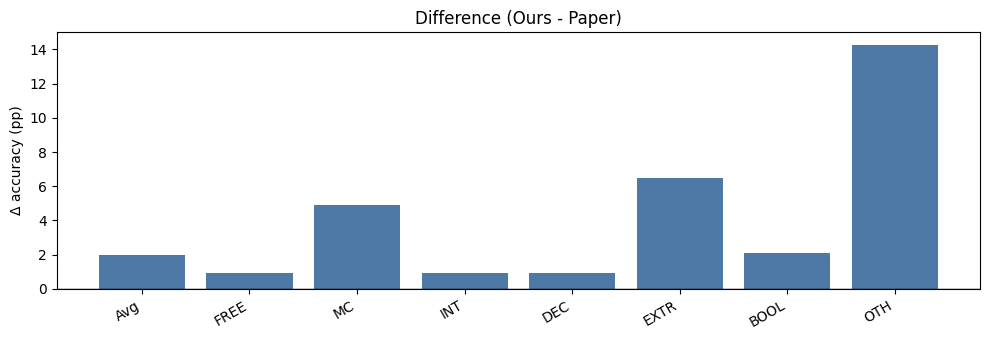

In [14]:
# Compare our TAPEX-base results to original paper numbers
import pandas as pd
import matplotlib.pyplot as plt

# Ours (from evaluate_acc cell)
ours = {
    "Avg": 17.70,
    "FREE": 8.25,
    "MC": 44.68,
    "INT": 9.60,
    "DEC": 3.00,
    "EXTR": 41.54,
    "BOOL": 49.22,
    "OTH": 35.24,
}

# Original paper (TAPEX_Base, Text-GT, Pre-trained PLM 22-09-29)
paper = {
    "Avg": 15.73,
    "FREE": 7.32,
    "MC": 39.76,
    "INT": 8.68,
    "DEC": 2.06,
    "EXTR": 35.06,
    "BOOL": 47.11,
    "OTH": 20.95,
}

metrics = list(ours.keys())
df = pd.DataFrame({
    "Metric": metrics,
    "Ours": [ours[m] for m in metrics],
    "Paper": [paper[m] for m in metrics],
})
df["Diff (Ours-Paper)"] = df["Ours"] - df["Paper"]

display(df)

# Bar plot: ours vs paper
plt.figure(figsize=(10,5))
width = 0.35
x = range(len(metrics))
plt.bar([i - width/2 for i in x], df["Ours"], width=width, label="Ours", color="skyblue")
plt.bar([i + width/2 for i in x], df["Paper"], width=width, label="Paper", color="salmon")
plt.xticks(x, metrics, rotation=30, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("TAPEX-Base accuracy vs. original paper")
plt.legend()
plt.tight_layout()
plt.show()

# Difference plot
plt.figure(figsize=(10,3.5))
plt.bar(metrics, df["Diff (Ours-Paper)"], color="#4e79a7")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Δ accuracy (pp)")
plt.title("Difference (Ours - Paper)")
plt.tight_layout()
plt.show()
